In [1]:
from pathlib import Path

import mlflow
import pandas as pd

from effcv.plotting_pipeline import (
    MetricCol,
    ParamCol,
    aggregate_experiments_by_seed,
    init_plot_env,
    plot_line_with_uncertainty,
    plot_scatter,
    replace_train_size_False_from_runs,
    user_gpu_mapping,
)

In [2]:
# TODO !!! must be absolute -> adapt path !!!
mlrun_abs_path = Path("/home/vossi/Dokumente/rotational_inv/hpc_output/mlruns")
OUT_DIR = Path("../plots")
init_plot_env(mlrun_abs_path, out_dir=OUT_DIR)

In [3]:
runs_500_imgsz640_smallbatch_carpk = mlflow.search_runs(
		max_results=700,
		filter_string=f"{ParamCol.APPROACH.value}='objectdetection' and {ParamCol.TRAIN_SIZE.value}='500' \
            and params.img_size ='640' and {ParamCol.DATASET.value} = 'carpk'",
		output_format="pandas",
		search_all_experiments=True,
	)
runs_500_imgsz640_smallbatch_carpk = replace_train_size_False_from_runs(runs_500_imgsz640_smallbatch_carpk)

runs_approaches = mlflow.search_runs(experiment_names=["carpk_train_size_yolo_local_iv","small_img_local"])
runs_approaches = replace_train_size_False_from_runs(runs_approaches)
runs_approaches = runs_approaches[runs_approaches[ParamCol.TRAIN_SIZE.value]== 791]

runs_imgsz640_smallbatch_carpk = mlflow.search_runs(
		max_results=700,
		filter_string=f"{ParamCol.APPROACH.value}='objectdetection' \
            and params.img_size ='640' and {ParamCol.DATASET.value}='carpk' and {ParamCol.BATCH_SIZE.value} != '16'",
		output_format="pandas",
		search_all_experiments=True,
	)
runs_imgsz640_smallbatch_carpk = replace_train_size_False_from_runs(runs_imgsz640_smallbatch_carpk)

In [ ]:
runs_500_imgsz640_smallbatch_carpk["tags.mlflow.user"]=runs_500_imgsz640_smallbatch_carpk["tags.mlflow.user"].map(user_gpu_mapping)
runs_imgsz640_smallbatch_carpk["tags.mlflow.user"]=runs_imgsz640_smallbatch_carpk["tags.mlflow.user"].map(user_gpu_mapping)
runs_imgsz640_smallbatch_carpk_agg = aggregate_experiments_by_seed(runs_imgsz640_smallbatch_carpk)
runs_approaches_agg = aggregate_experiments_by_seed(runs_approaches)

# Übersicht Experimente 

### Uce-Case Daten
- Experimente mit provisorischen Labels in vorigen Sprints zu Trainingsmengen
- seit Montag manuell gelabelte bboxes für Trainingsdaten
- Experimente folgen in Use-Case Bearbeitung

## Experimente Object Counting mit vortrainierten Object Detection Modellen

| **Datensatz**       | **Bildgrößen**             | **GPUs**                 | **Trainingsdatenmengen** <br> (stratifiziert nach Objektanzahl)             | **Modelle**            | **Augmentierung**                               |  
|----------------------|----------------------------|--------------------------|--------------------------------------|------------------------|------------------------------------------------|
| **Carpk**            | **2** <br>1280 (original), 640      | **3** <br> RTX A500 Laptop GPU, NVIDIA H100-SXM5, Nvidia Tesla V100 | 6 (50, 100, 200, 300, 500, 791)      | yolov8n, yolov11n      | Ultralytics augment Parametersuch <br>  feste Parameter pro Datensatz |  
| **Synthetic Cells**  | **1** <br> 256               | **3** <br> RTX A500 Laptop GPU, NVIDIA H100-SXM5, Nvidia Tesla V100 | 3 (50, 100, 128)                     | yolov8n, yolov11n      | Ultralytics augment Parametersuche <br>  feste Parameter pro Datensatz | 



### Objekte im carpk Datensatz (Aufteilung der subsets im Datensatz)
- für train_size Experimente -> Stratifizierung nach Anzahl Objekte

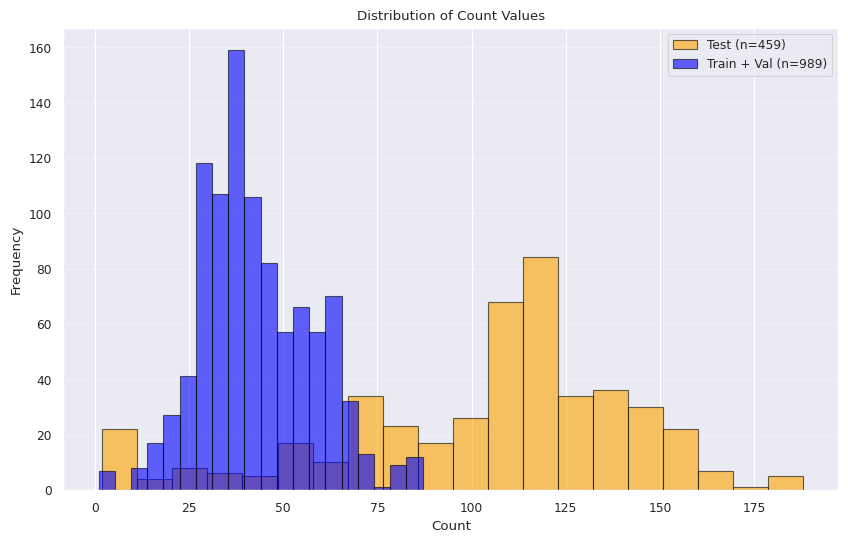

## carpk object detection
### train_size und Energie im hardware Vergleich

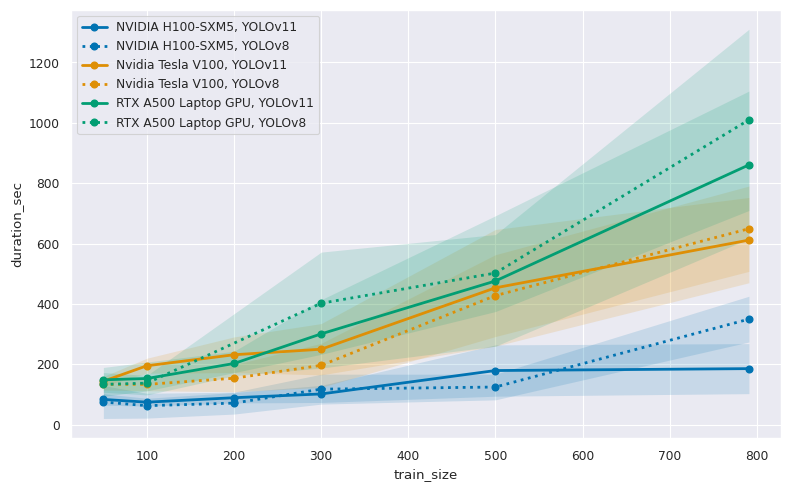

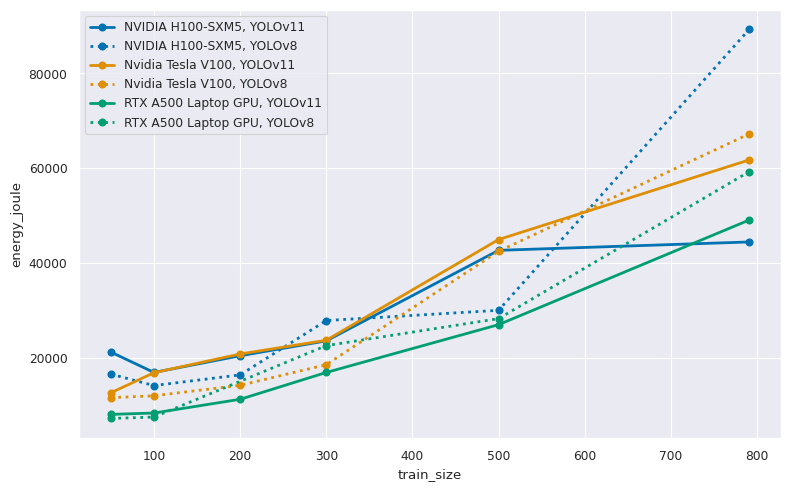

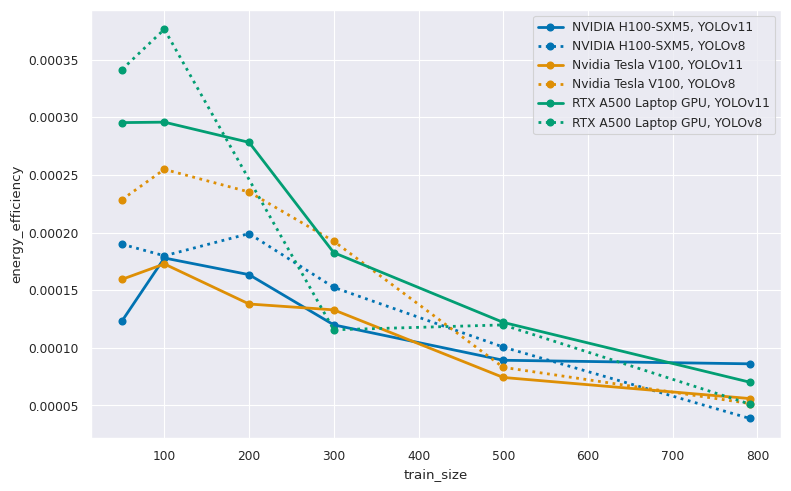

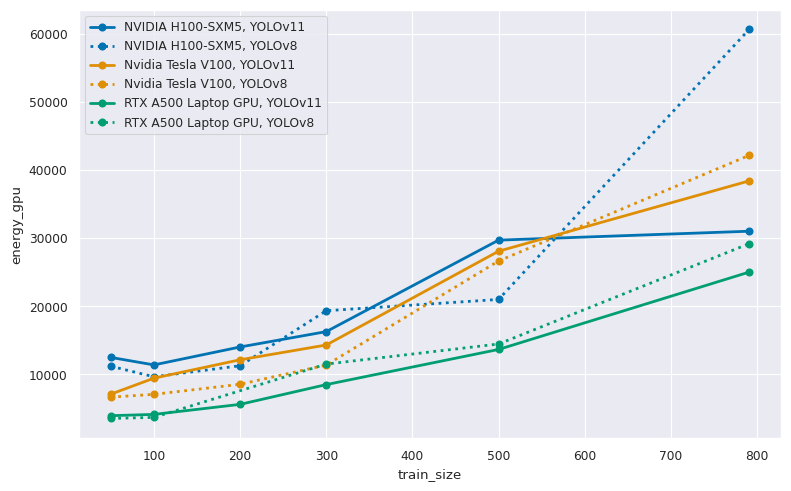

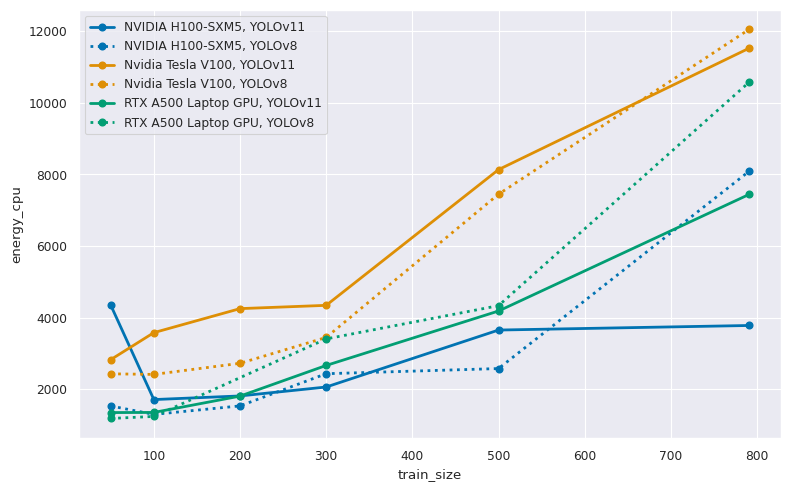

In [5]:
# train_size plot hardware compare - carpk
# TODO across two datasets?
assert isinstance(runs_imgsz640_smallbatch_carpk_agg, pd.DataFrame)
runs_imgsz640_smallbatch_carpk_agg[f"{MetricCol.ENERGY_JOULE.value}_var"] = 0
runs_imgsz640_smallbatch_carpk_agg[f"{MetricCol.ENERGY_EFFICIENCY.value}_var"] = 0
runs_imgsz640_smallbatch_carpk_agg[f"{MetricCol.ENERGY_CPU.value}_var"] = 0
runs_imgsz640_smallbatch_carpk_agg[f"{MetricCol.ENERGY_GPU.value}_var"] = 0


for y in [MetricCol.DURATION_SEC, MetricCol.ENERGY_JOULE, MetricCol.ENERGY_EFFICIENCY, MetricCol.ENERGY_GPU, MetricCol.ENERGY_CPU]:
	plot_line_with_uncertainty(runs_imgsz640_smallbatch_carpk_agg, x_col=ParamCol.TRAIN_SIZE.value, 
                              y_col=y, alpha=0.15,
                              hue_param="tags.mlflow.user",style_param=ParamCol.MODEL_NAME.value, show=True)

### train_size = 500, hardware compare, Energy vs duration

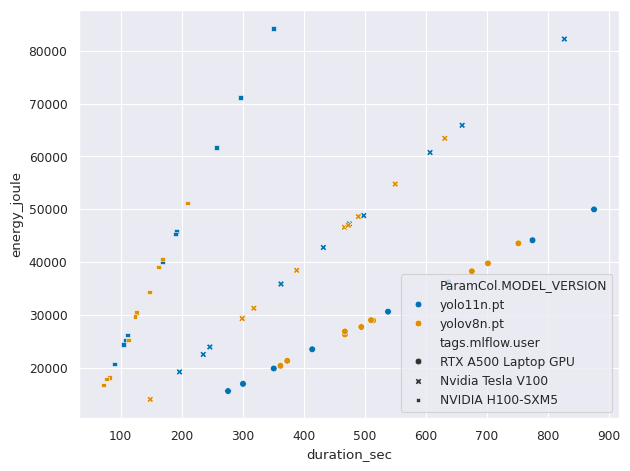

In [6]:

assert isinstance(runs_500_imgsz640_smallbatch_carpk, pd.DataFrame)
plot_scatter(runs_500_imgsz640_smallbatch_carpk, y_col=MetricCol.ENERGY_JOULE, x_col=MetricCol.DURATION_SEC, 
             symbol_param="tags.mlflow.user", hue_param=ParamCol.MODEL_VERSION, dataset_name="carpk",out_dir=OUT_DIR, show=True)

## Vergleich Density Maps und object detection carpk Datensatz (unter Vorbehalt)
- auf Laptop GPU; voller carpk Datensatz
- jeder Punkt entspricht einem Run (nicht aggregiert)
- Density Maps entspricht nicht aktuellem Stand der besten Modelle (unter anderem kleine Bildgröße)

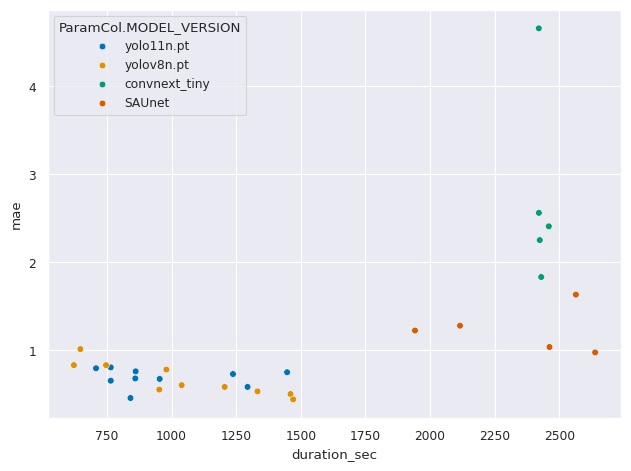

In [7]:
plot_scatter(runs_approaches, y_col=MetricCol.MAE, x_col=MetricCol.DURATION_SEC, hue_param=ParamCol.MODEL_VERSION, show=True, symbol_param=None)

## train_size synthetic cells Object detection
## hardware compare 

In [ ]:
runs_synth = mlflow.search_runs(
		max_results=200,
		filter_string=f"{ParamCol.APPROACH.value}='objectdetection' and {ParamCol.TRAIN_SIZE.value} != '50' \
            and {ParamCol.TRAIN_SIZE.value} != 'False' and {ParamCol.DATASET.value} = 'synthcells'",
		output_format="pandas",
		search_all_experiments=True,
	)
runs_synth = replace_train_size_False_from_runs(runs_synth)

runs_synth_trainsize = mlflow.search_runs(
		max_results=200,
		filter_string=f"{ParamCol.APPROACH.value}='objectdetection' \
            {ParamCol.DATASET.value}='synthcells'",
		output_format="pandas",
		search_all_experiments=True,
	)
runs_synth_trainsize = replace_train_size_False_from_runs(runs_synth_trainsize)
runs_synth["tags.mlflow.user"]=runs_synth["tags.mlflow.user"].map(user_gpu_mapping)
runs_synth_trainsize["tags.mlflow.user"]=runs_synth_trainsize["tags.mlflow.user"].map(user_gpu_mapping)
runs_synth_trainsize_agg = aggregate_experiments_by_seed(runs_synth_trainsize)


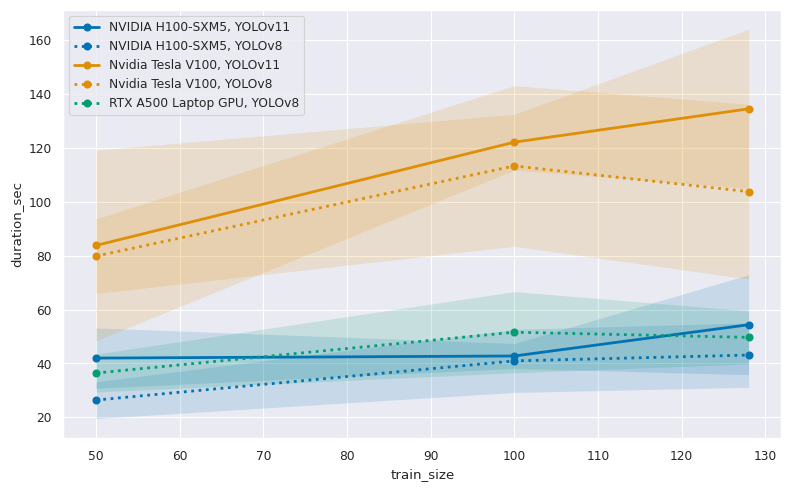

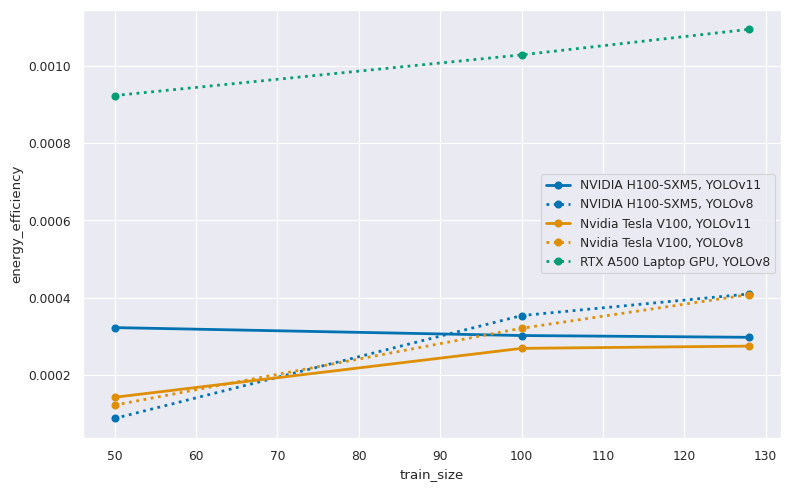

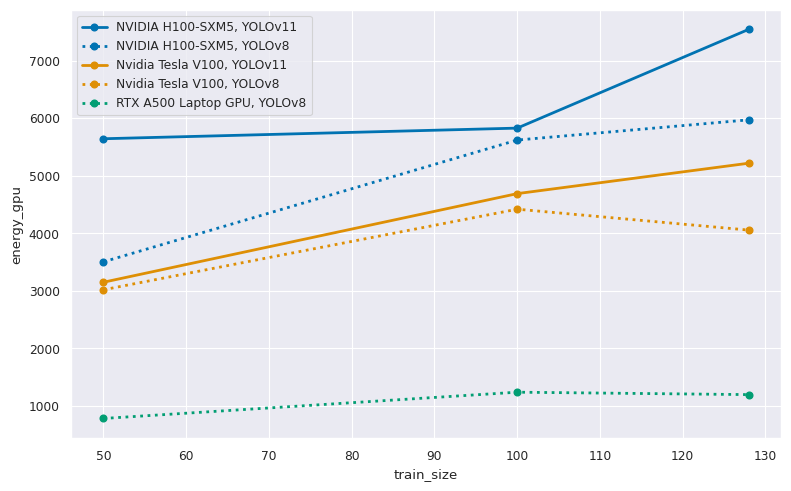

In [9]:
# train_size plot hardware compare - synth
# TODO across two datasets
assert isinstance(runs_synth_trainsize_agg, pd.DataFrame)
runs_synth_trainsize_agg[f"{MetricCol.ENERGY_JOULE.value}_var"] = 0
runs_synth_trainsize_agg[f"{MetricCol.ENERGY_GPU.value}_var"] = 0
runs_synth_trainsize_agg[f"{MetricCol.ENERGY_CPU.value}_var"] = 0
runs_synth_trainsize_agg[f"{MetricCol.ENERGY_EFFICIENCY.value}_var"] = 0

for y in [MetricCol.DURATION_SEC, MetricCol.ENERGY_EFFICIENCY, MetricCol.ENERGY_GPU]:
	plot_line_with_uncertainty(runs_synth_trainsize_agg, x_col=ParamCol.TRAIN_SIZE.value, 
                              y_col=y, alpha=0.15,
                              hue_param="tags.mlflow.user",style_param=ParamCol.MODEL_NAME.value, show=True)